## 1 · Environment Setup

In [1]:
!pip install -q torch torchvision pandas pillow tqdm

In [2]:
import os
import re
import math
import random
import string
import pickle
from collections import Counter
from PIL import Image

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


## 2 · Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR      = '/content/drive/MyDrive/caption_data'
SAVE_DIR      = os.path.join(BASE_DIR, 'trained')
os.makedirs(SAVE_DIR, exist_ok=True)

# Copy data to local disk for faster I/O
print("Copying data to local disk...")
!cp -r /content/drive/MyDrive/caption_data/Images /content/Images
!cp /content/drive/MyDrive/caption_data/captions.txt /content/captions.txt
print("Done.")

CAPTIONS_FILE = '/content/captions.txt'
IMAGES_DIR    = '/content/Images'

print(f'  captions : {CAPTIONS_FILE}')
print(f'  images   : {IMAGES_DIR}')
print(f'  save_dir : {SAVE_DIR}')

Mounted at /content/drive
Copying data to local disk...
Done.
  captions : /content/captions.txt
  images   : /content/Images
  save_dir : /content/drive/MyDrive/caption_data/trained


## 3 · Hyperparameters

In [4]:
MIN_WORD_FREQ = 3       # words appearing fewer times are mapped to <UNK>
TRAIN_SPLIT   = 0.80    # fraction of *images* used for training
IMG_SIZE      = 224

EMBED_DIM   = 256
HIDDEN_DIM  = 512
NUM_LAYERS  = 1
DROPOUT     = 0.5


BATCH_SIZE  = 64
NUM_EPOCHS  = 30
LR          = 3e-4
GRAD_CLIP   = 1.0
LR_PATIENCE = 3        # epochs of no val improvement before halving LR
LR_FACTOR   = 0.5
EARLY_STOP_PATIENCE = 5  # epochs of no val improvement before stopping training


BEAM_WIDTH  = 5        # beam search width used at inference time

PAD_TOKEN   = '<PAD>'
UNK_TOKEN   = '<UNK>'
START_TOKEN = '<START>'
END_TOKEN   = '<END>'

print('Hyperparameters loaded.')

Hyperparameters loaded.


## 4 · Data Loading & Text Cleaning

In [5]:
def load_captions(filepath: str) -> pd.DataFrame:
    """
    Read captions.txt.
    Expected format (Flickr8k style): each line is  'image_file,caption'
    or tab-separated.  The first column is the image filename.
    """
    rows = []
    with open(filepath, 'r', encoding='utf-8') as fh:
        for i, line in enumerate(fh):
            line = line.strip()
            if not line or line.lower().startswith('image'):
                continue  # skip header or blank lines
            # Support comma or tab as separator
            if '\t' in line:
                parts = line.split('\t', 1)
            else:
                parts = line.split(',', 1)
            if len(parts) != 2:
                continue
            image_name, caption = parts[0].strip(), parts[1].strip()
            # Some Flickr8k files append '#N' to the filename  (e.g. dog.jpg#0)
            image_name = image_name.split('#')[0]
            rows.append({'image': image_name, 'caption': caption})
    df = pd.DataFrame(rows)
    print(f'Loaded {len(df):,} caption rows for {df["image"].nunique():,} unique images.')
    return df


df_raw = load_captions(CAPTIONS_FILE)
df_raw.head()

Loaded 40,455 caption rows for 8,091 unique images.


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [6]:
ARTICLES = {'a', 'an', 'the'}


def clean_caption(text: str) -> str:
    """Lowercase, remove punctuation & digits, strip articles and 1-char words."""
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove digits
    text = re.sub(r'\d+', '', text)
    # Tokenise on whitespace
    tokens = text.split()
    # Drop single-character tokens and articles
    tokens = [t for t in tokens if len(t) > 1 and t not in ARTICLES]
    # Wrap with START / END
    tokens = [START_TOKEN] + tokens + [END_TOKEN]
    return ' '.join(tokens)


df = df_raw.copy()
df['caption'] = df['caption'].apply(clean_caption)

print('Sample cleaned captions:')
for _, row in df.head(3).iterrows():
    print(f'  {row["image"]}  →  {row["caption"]}')

Sample cleaned captions:
  1000268201_693b08cb0e.jpg  →  <START> child in pink dress is climbing up set of stairs in entry way <END>
  1000268201_693b08cb0e.jpg  →  <START> girl going into wooden building <END>
  1000268201_693b08cb0e.jpg  →  <START> little girl climbing into wooden playhouse <END>


## 5 · Vocabulary

In [7]:
class Vocabulary:
    """Word ↔ index mapping with frequency-based filtering."""

    def __init__(self, min_freq: int = 5):
        self.min_freq = min_freq
        # Reserve indices for special tokens
        self.word2idx = {
            PAD_TOKEN: 0,
            UNK_TOKEN: 1,
            START_TOKEN: 2,
            END_TOKEN: 3,
        }
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self._counter: Counter = Counter()

    # Special token indices (properties for convenience)
    @property
    def pad_idx(self):   return self.word2idx[PAD_TOKEN]
    @property
    def unk_idx(self):   return self.word2idx[UNK_TOKEN]
    @property
    def start_idx(self): return self.word2idx[START_TOKEN]
    @property
    def end_idx(self):   return self.word2idx[END_TOKEN]

    def __len__(self):
        return len(self.word2idx)

    def build(self, captions: pd.Series) -> None:
        """Count all words in *captions* and add those above min_freq."""
        for caption in captions:
            for word in caption.split():
                if word not in (PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN):
                    self._counter[word] += 1
        for word, freq in self._counter.items():
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word
        print(f'Vocabulary built: {len(self):,} tokens  '
              f'(min_freq={self.min_freq}, '
              f'rare_words_collapsed_to_UNK: '
              f'{sum(1 for f in self._counter.values() if f < self.min_freq):,})')

    def numericalize(self, sentence: str) -> list[int]:
        """Convert a whitespace-tokenised string to a list of indices."""
        return [
            self.word2idx.get(word, self.unk_idx)
            for word in sentence.split()
        ]

    def decode(self, indices: list[int], skip_special: bool = True) -> str:
        """Convert indices back to a human-readable string."""
        special = {self.pad_idx, self.start_idx, self.end_idx}
        words = []
        for idx in indices:
            if skip_special and idx in special:
                if idx == self.end_idx:
                    break
                continue
            words.append(self.idx2word.get(idx, UNK_TOKEN))
        return ' '.join(words)


# Build vocabulary from ALL captions (train + val share the same vocab)
vocab = Vocabulary(min_freq=MIN_WORD_FREQ)
vocab.build(df['caption'])

print(f'\nVocabulary size : {len(vocab)}')
print(f'PAD idx         : {vocab.pad_idx}')
print(f'START idx       : {vocab.start_idx}')
print(f'END idx         : {vocab.end_idx}')

Vocabulary built: 4,074 tokens  (min_freq=3, rare_words_collapsed_to_UNK: 4,693)

Vocabulary size : 4074
PAD idx         : 0
START idx       : 2
END idx         : 3


## 6 · Train / Validation Split (by Image)

In [8]:
all_images = df['image'].unique().tolist()
random.shuffle(all_images)

n_train    = int(len(all_images) * TRAIN_SPLIT)
train_imgs = set(all_images[:n_train])
val_imgs   = set(all_images[n_train:])

df_train = df[df['image'].isin(train_imgs)].reset_index(drop=True)
df_val   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f'Train: {len(train_imgs):,} images  ({len(df_train):,} captions)')
print(f'Val  : {len(val_imgs):,} images  ({len(df_val):,} captions)')

# Sanity-check: no image appears in both splits
assert train_imgs.isdisjoint(val_imgs), 'Leak detected!'
print('No image leakage between splits. ✓')

Train: 6,472 images  (32,360 captions)
Val  : 1,619 images  (8,095 captions)
No image leakage between splits. ✓


## 7 · Dataset & DataLoader

In [9]:
# ImageNet normalisation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Transforms defined.')

Transforms defined.


In [10]:
class CaptionDataset(Dataset):
    """
    Returns (image_tensor, caption_indices) pairs.
    Each (image, caption) row in the DataFrame becomes one sample.
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        images_dir: str,
        vocabulary: Vocabulary,
        transform=None,
    ):
        self.df         = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.vocab      = vocabulary
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row     = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['image'])

        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
        except (FileNotFoundError, OSError):
            # Return a blank image if file is missing (graceful degradation)
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE))

        if self.transform:
            image = self.transform(image)

        # Numericalize caption
        caption_ids = torch.tensor(
            self.vocab.numericalize(row['caption']),
            dtype=torch.long,
        )
        return image, caption_ids


def collate_fn(batch, pad_idx: int):
    """
    Pads variable-length caption sequences to the length of the longest
    caption in the batch.  Returns (images, captions) tensors.
    """
    images, captions = zip(*batch)

    # Stack images  →  (B, C, H, W)
    images = torch.stack(images, dim=0)

    # Pad captions  →  (B, T_max)
    captions = torch.nn.utils.rnn.pad_sequence(
        captions,
        batch_first=True,
        padding_value=pad_idx,
    )
    return images, captions


import functools

train_dataset = CaptionDataset(df_train, IMAGES_DIR, vocab, train_transform)
val_dataset   = CaptionDataset(df_val,   IMAGES_DIR, vocab, val_transform)

_collate = functools.partial(collate_fn, pad_idx=vocab.pad_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=(DEVICE.type == 'cuda'),
    collate_fn=_collate,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=(DEVICE.type == 'cuda'),
    collate_fn=_collate,
)

print(f'Train batches : {len(train_loader):,}')
print(f'Val batches   : {len(val_loader):,}')

# Quick smoke-test
sample_imgs, sample_caps = next(iter(train_loader))
print(f'\nSample batch — images: {tuple(sample_imgs.shape)}, '
      f'captions: {tuple(sample_caps.shape)}')

Train batches : 506
Val batches   : 127


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Sample batch — images: (64, 3, 224, 224), captions: (64, 17)


## 8 · Model Architecture

In [11]:
class EncoderCNN(nn.Module):
    """
    Frozen ResNet18 backbone + trainable linear projection.

    The backbone is kept frozen so that the rich ImageNet representations
    are preserved on our small dataset (8k images).  Only the projection
    head is updated during training.
    """

    def __init__(self, embed_dim: int):
        super().__init__()

        # Load pretrained ResNet18
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Remove the final classification layer
        backbone_out_dim = backbone.fc.in_features          # 512 for ResNet18
        backbone.fc     = nn.Identity()

        self.backbone = backbone

        # Freeze all backbone parameters first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze only layer4 so it can adapt to our image distribution
        # while keeping the rest of the backbone frozen (saves VRAM and
        # avoids overfitting on 8k images).
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        # Trainable projection head: 512 → embed_dim
        self.projection = nn.Sequential(
            nn.Linear(backbone_out_dim, embed_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """Return image feature vectors of shape (B, embed_dim)."""
        # layer4 is now in train mode and produces gradients;
        # earlier layers are still frozen so we can skip no_grad only
        # for the frozen prefix and let autograd handle layer4.
        features = self.backbone(images)       # (B, 512)
        return self.projection(features)       # (B, embed_dim)


# Quick test
_enc = EncoderCNN(EMBED_DIM).to(DEVICE)
_dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
print('Encoder output shape:', _enc(_dummy).shape)  # expect (2, 256)
del _enc, _dummy

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


Encoder output shape: torch.Size([2, 256])


In [12]:
class DecoderLSTM(nn.Module):
    """
    LSTM language model conditioned on image features.

    The image feature vector is treated as the first input token (position 0).
    During training, teacher forcing feeds the ground-truth word at each
    subsequent step, making training stable and fast.

    Input sequence layout (teacher forcing):
      position 0 : image feature  (projected to embed_dim)
      position 1 : <START> embedding
      position 2 : word_1 embedding
      ...
      position T : word_{T-1} embedding

    Targets (what we ask the model to predict):
      position 0 : <START>
      position 1 : word_1
      ...
      position T : <END>
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim:  int,
        hidden_dim: int,
        num_layers: int,
        dropout:    float,
        pad_idx:    int,
    ):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm    = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim, vocab_size)
        self.embed_dim = embed_dim

    def forward(
        self,
        img_features: torch.Tensor,   # (B, embed_dim)
        captions:     torch.Tensor,   # (B, T)  — includes <START>, excludes <END>
    ) -> torch.Tensor:
        """
        Returns logits of shape (B, T, vocab_size).
        """
        B, T = captions.shape

        # Embed ground-truth caption words  →  (B, T, embed_dim)
        word_embs = self.dropout(self.embed(captions))

        # Treat image features as the first token  →  (B, 1, embed_dim)
        img_token = img_features.unsqueeze(1)          # (B, 1, embed_dim)

        # Full input: [img_token | word embeddings]  →  (B, T+1, embed_dim)
        # The last word embedding is not needed as input (it maps to <END>)
        lstm_input = torch.cat([img_token, word_embs[:, :-1, :]], dim=1)  # (B, T, embed_dim)

        # Run LSTM
        lstm_out, _ = self.lstm(lstm_input)             # (B, T, hidden_dim)
        logits = self.fc(self.dropout(lstm_out))        # (B, T, vocab_size)
        return logits

    @torch.no_grad()
    def generate(
        self,
        img_features: torch.Tensor,   # (1, embed_dim)
        vocab: 'Vocabulary',
        max_len: int = 40,
    ) -> list[int]:
        """Greedy decoding — kept for reference; beam_search is preferred."""
        self.eval()
        generated = [vocab.start_idx]
        hidden    = None

        x = img_features.unsqueeze(1)
        out, hidden = self.lstm(x, hidden)

        for _ in range(max_len):
            word_idx  = generated[-1]
            word_emb  = self.embed(torch.tensor([[word_idx]], device=img_features.device))
            out, hidden = self.lstm(word_emb, hidden)
            logit     = self.fc(out.squeeze(1))
            pred      = logit.argmax(dim=-1).item()
            if pred == vocab.end_idx:
                break
            generated.append(pred)

        return generated[1:]

    @torch.no_grad()
    def beam_search(
        self,
        img_features: torch.Tensor,   # (1, embed_dim)
        vocab: 'Vocabulary',
        beam_width: int = 5,
        max_len:    int = 40,
    ) -> list[int]:
        """
        Beam search decoding.

        Maintains `beam_width` partial hypotheses at each step, scoring by
        cumulative log-probability.  Returns the single best complete sequence
        (without <START>/<END>).
        """
        import math as _math
        self.eval()
        device = img_features.device

        # Initialise: feed image feature as step 0
        x = img_features.unsqueeze(1)           # (1, 1, embed_dim)
        out, hidden = self.lstm(x)              # hidden: (num_layers, 1, hidden_dim)

        # Each beam entry: (log_prob, token_list, hidden_state)
        beams = [(0.0, [vocab.start_idx], hidden)]

        completed = []

        for _ in range(max_len):
            candidates = []
            for log_prob, tokens, h in beams:
                last_token = tokens[-1]
                if last_token == vocab.end_idx:
                    completed.append((log_prob, tokens))
                    continue

                word_emb = self.embed(
                    torch.tensor([[last_token]], device=device)
                )                               # (1, 1, embed_dim)
                out, new_h = self.lstm(word_emb, h)
                log_probs  = torch.log_softmax(
                    self.fc(out.squeeze(1)), dim=-1
                )                               # (1, vocab_size)

                # Take top-k next tokens
                topk_lp, topk_idx = log_probs[0].topk(beam_width)
                for lp, idx in zip(topk_lp.tolist(), topk_idx.tolist()):
                    candidates.append((
                        log_prob + lp,
                        tokens + [idx],
                        new_h,
                    ))

            if not candidates:
                break

            # Keep best beam_width beams
            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_width]

        # If no beam finished with <END>, use the best open beam
        if not completed:
            completed = [(lp, toks) for lp, toks, _ in beams]

        # Pick highest-scoring complete sequence
        best = max(completed, key=lambda x: x[0])
        seq  = best[1]

        # Strip <START> and <END>
        seq = [t for t in seq if t not in (vocab.start_idx, vocab.end_idx)]
        return seq


print('DecoderLSTM class defined.')

DecoderLSTM class defined.


In [13]:
class ImageCaptioningModel(nn.Module):
    """Thin wrapper that composes EncoderCNN + DecoderLSTM."""

    def __init__(
        self,
        vocab_size: int,
        embed_dim:  int  = 256,
        hidden_dim: int  = 512,
        num_layers: int  = 1,
        dropout:    float = 0.5,
        pad_idx:    int  = 0,
    ):
        super().__init__()
        self.encoder = EncoderCNN(embed_dim)
        self.decoder = DecoderLSTM(
            vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx
        )

    def forward(
        self,
        images:   torch.Tensor,   # (B, 3, H, W)
        captions: torch.Tensor,   # (B, T)
    ) -> torch.Tensor:            # (B, T, vocab_size)
        features = self.encoder(images)                 # (B, embed_dim)
        logits   = self.decoder(features, captions)     # (B, T, vocab_size)
        return logits

    def caption_image(
        self,
        image:      torch.Tensor,
        vocab:      'Vocabulary',
        max_len:    int = 40,
        beam_width: int = 5,
    ) -> str:
        """Convenience method: raw image tensor → human-readable caption.

        Uses beam search by default (beam_width=5).  Set beam_width=1 to
        fall back to greedy decoding.
        """
        self.eval()
        with torch.no_grad():
            features = self.encoder(image.unsqueeze(0))
            if beam_width > 1:
                indices = self.decoder.beam_search(features, vocab, beam_width, max_len)
            else:
                indices = self.decoder.generate(features, vocab, max_len)
        return vocab.decode(indices)


# Instantiate
model = ImageCaptioningModel(
    vocab_size = len(vocab),
    embed_dim  = EMBED_DIM,
    hidden_dim = HIDDEN_DIM,
    num_layers = NUM_LAYERS,
    dropout    = DROPOUT,
    pad_idx    = vocab.pad_idx,
).to(DEVICE)

# Parameter count
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}  '
      f'({100*trainable_params/total_params:.1f} %)')

Total parameters     : 16,017,706
Trainable parameters : 13,234,922  (82.6 %)


## 9 · Training Setup

In [14]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

# Use separate param groups so layer4 trains at a smaller LR than the
# decoder, preventing the pretrained weights from being perturbed too quickly.
optimizer = optim.Adam([
    {'params': model.decoder.parameters(),            'lr': LR},
    {'params': model.encoder.projection.parameters(), 'lr': LR},
    {'params': model.encoder.backbone.layer4.parameters(),
     'lr': LR * 0.1,    # 10× smaller — fine-tunes without clobbering ImageNet init
     'weight_decay': 1e-4},
])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
)

print('Loss   : CrossEntropyLoss  (pad_idx ignored)')
print('Optim  : Adam  lr={:.0e}'.format(LR))
print(f'Sched  : ReduceLROnPlateau  patience={LR_PATIENCE}  factor={LR_FACTOR}')

Loss   : CrossEntropyLoss  (pad_idx ignored)
Optim  : Adam  lr=3e-04
Sched  : ReduceLROnPlateau  patience=3  factor=0.5


## 10 · Training & Validation Functions

In [15]:
def train_one_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device:    torch.device,
    grad_clip: float,
) -> float:
    """Train for one epoch and return average cross-entropy loss."""
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for images, captions in tqdm(loader, desc='  train', leave=False):
        images   = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        optimizer.zero_grad()

        # Forward pass
        logits = model(images, captions)   # (B, T, V)

        # Reshape for CrossEntropyLoss: (B*T, V) vs (B*T,)
        B, T, V = logits.shape
        loss = criterion(
            logits.reshape(B * T, V),
            captions.reshape(B * T),
        )

        loss.backward()

        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        # Accumulate loss weighted by number of non-pad tokens
        non_pad = (captions != vocab.pad_idx).sum().item()
        total_loss   += loss.item() * non_pad
        total_tokens += non_pad

    return total_loss / max(total_tokens, 1)


@torch.no_grad()
def validate_one_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    criterion: nn.Module,
    device:    torch.device,
) -> float:
    """Evaluate on validation set and return average cross-entropy loss."""
    model.eval()
    total_loss   = 0.0
    total_tokens = 0

    for images, captions in tqdm(loader, desc='  val  ', leave=False):
        images   = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        logits = model(images, captions)
        B, T, V = logits.shape
        loss = criterion(
            logits.reshape(B * T, V),
            captions.reshape(B * T),
        )

        non_pad = (captions != vocab.pad_idx).sum().item()
        total_loss   += loss.item() * non_pad
        total_tokens += non_pad

    return total_loss / max(total_tokens, 1)


print('Training functions defined.')

Training functions defined.


## 11 · Run Training

In [ ]:
CHECKPOINT_PATH = os.path.join(SAVE_DIR, 'best_model.pth')

history = {'train_loss': [], 'val_loss': [], 'lr': []}
best_val_loss = math.inf
epochs_no_improve = 0

print('='*65)
print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Val Loss":>10}  {"Perplexity":>10}  {"LR":>10}')
print('='*65)

for epoch in range(1, NUM_EPOCHS + 1):

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, GRAD_CLIP
    )
    val_loss = validate_one_epoch(
        model, val_loader, criterion, DEVICE
    )

    current_lr = optimizer.param_groups[0]['lr']
    perplexity  = math.exp(val_loss)

    # Step scheduler on validation loss
    scheduler.step(val_loss)

    # Checkpoint best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save({
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss':        val_loss,
            'vocab_size':      len(vocab),
            'hyperparams': {
                'embed_dim':  EMBED_DIM,
                'hidden_dim': HIDDEN_DIM,
                'num_layers': NUM_LAYERS,
                'dropout':    DROPOUT,
            },
        }, CHECKPOINT_PATH)
        marker = ' ← best'
    else:
        epochs_no_improve += 1
        marker = ''

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(current_lr)

    print(f'{epoch:>6}  {train_loss:>10.4f}  {val_loss:>10.4f}  '
          f'{perplexity:>10.2f}  {current_lr:>10.2e}{marker}')

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch} '
              f'(no val improvement for {EARLY_STOP_PATIENCE} epochs).')
        break

print('='*65)
print(f'Training complete.  Best val loss: {best_val_loss:.4f}')

 Epoch  Train Loss    Val Loss  Perplexity          LR


  train:   0%|          | 0/506 [00:00<?, ?it/s]

  val  :   0%|          | 0/127 [00:00<?, ?it/s]

     1      4.7374      4.1149       61.25    3.00e-04 ← best


  train:   0%|          | 0/506 [00:00<?, ?it/s]

...

  val  :   0%|          | 0/127 [00:00<?, ?it/s]

    29      2.3293      3.1148       22.53    7.50e-05


  train:   0%|          | 0/506 [00:00<?, ?it/s]

  val  :   0%|          | 0/127 [00:00<?, ?it/s]

    30      2.3193      3.1176       22.59    7.50e-05
Training complete.  Best val loss: 3.0977


## 12 · Save All Artifacts to Google Drive

In [ ]:
import json

vocab_path = os.path.join(SAVE_DIR, 'vocab.pkl')
with open(vocab_path, 'wb') as f:
    pickle.dump(vocab, f)
print(f'Vocabulary saved → {vocab_path}')

history_path = os.path.join(SAVE_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'Training history saved → {history_path}')

final_path = os.path.join(SAVE_DIR, 'final_model.pth')
torch.save(model.state_dict(), final_path)
print(f'Final model weights saved → {final_path}')

config = {
    'embed_dim':      EMBED_DIM,
    'hidden_dim':     HIDDEN_DIM,
    'num_layers':     NUM_LAYERS,
    'dropout':        DROPOUT,
    'vocab_size':     len(vocab),
    'pad_idx':        vocab.pad_idx,
    'img_size':       IMG_SIZE,
    'min_word_freq':  MIN_WORD_FREQ,
    'best_val_loss':  best_val_loss,
    'num_epochs':     NUM_EPOCHS,
}
config_path = os.path.join(SAVE_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'Config saved → {config_path}')

print('\nAll artifacts saved to:', SAVE_DIR)

Vocabulary saved → /content/drive/MyDrive/caption_data/trained/vocab.pkl
Training history saved → /content/drive/MyDrive/caption_data/trained/training_history.json
Final model weights saved → /content/drive/MyDrive/caption_data/trained/final_model.pth
Config saved → /content/drive/MyDrive/caption_data/trained/config.json

All artifacts saved to: /content/drive/MyDrive/caption_data/trained


## 13 · Loss Curves

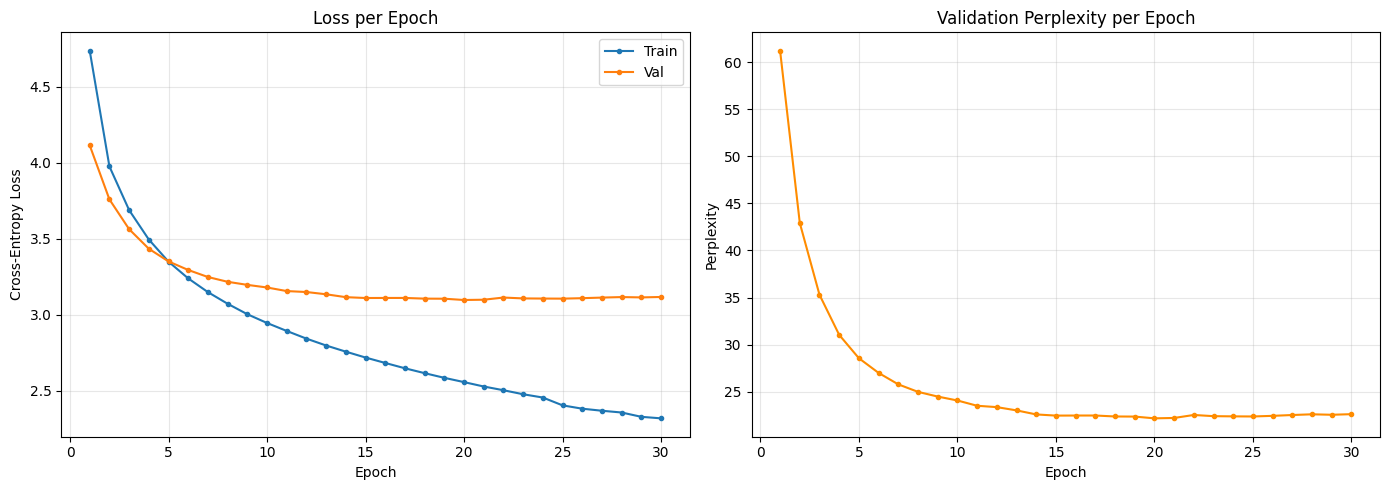

Plot saved → /content/drive/MyDrive/caption_data/trained/loss_curves.png


In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', marker='o', markersize=3)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   marker='o', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Loss per Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity
axes[1].plot(epochs_range, [math.exp(l) for l in history['val_loss']],
             color='darkorange', marker='o', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Validation Perplexity per Epoch')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(SAVE_DIR, 'loss_curves.png')
plt.savefig(plot_path, dpi=120)
plt.show()
print(f'Plot saved → {plot_path}')

In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

model.eval()
references = []
hypotheses = []

# Group val captions by image
val_grouped = df_val.groupby('image')['caption'].apply(list).reset_index()

with torch.no_grad():
    for _, row in tqdm(val_grouped.iterrows(), total=len(val_grouped), desc='BLEU eval'):
        img_path = os.path.join(IMAGES_DIR, row['image'])
        try:
            pil_img = Image.open(img_path).convert('RGB')
        except:
            continue

        img_tensor = val_transform(pil_img).to(DEVICE)
        caption    = model.caption_image(img_tensor, vocab, max_len=40, beam_width=BEAM_WIDTH)

        # References: list of tokenised human captions (excluding START/END)
        refs = [
            [w for w in c.split() if w not in (START_TOKEN, END_TOKEN)]
            for c in row['caption']
        ]
        hyp = caption.split()

        references.append(refs)
        hypotheses.append(hyp)

smoother = SmoothingFunction().method1
bleu1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0), smoothing_function=smoother)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0), smoothing_function=smoother)
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)

print(f'BLEU-1: {bleu1:.4f}')
print(f'BLEU-2: {bleu2:.4f}')
print(f'BLEU-4: {bleu4:.4f}')

# Save to Drive
bleu_scores = {'BLEU-1': bleu1, 'BLEU-2': bleu2, 'BLEU-4': bleu4}
with open(os.path.join(SAVE_DIR, 'bleu_scores.json'), 'w') as f:
    json.dump(bleu_scores, f, indent=2)
print('BLEU scores saved to Drive.')

BLEU eval:   0%|          | 0/1619 [00:00<?, ?it/s]

BLEU-1: 0.5180
BLEU-2: 0.3343
BLEU-4: 0.1397
BLEU scores saved to Drive.


## 14 · Qualitative Inference (Greedy Decoding)

Best checkpoint loaded (epoch 20, val_loss=3.0977)


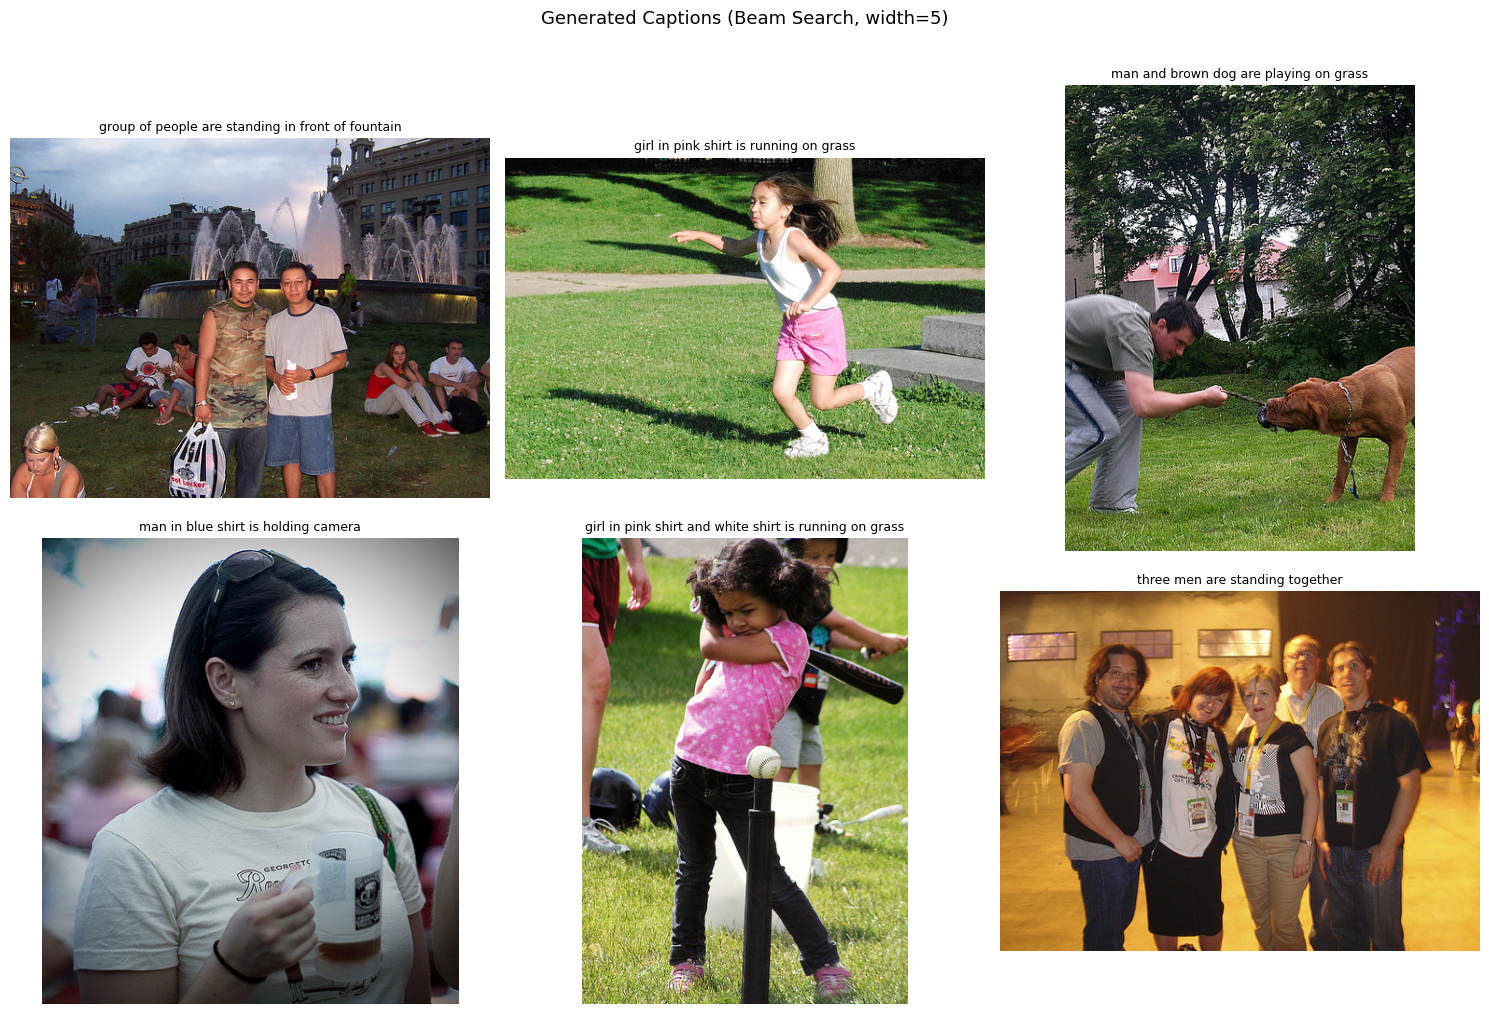

Sample captions saved → /content/drive/MyDrive/caption_data/trained/sample_captions.png


In [ ]:
import matplotlib.pyplot as plt

# Load the best checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f"Best checkpoint loaded (epoch {checkpoint['epoch']}, "
      f"val_loss={checkpoint['val_loss']:.4f})")

# Sample 6 random validation images
sample_rows = df_val.drop_duplicates('image').sample(6, random_state=SEED)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = os.path.join(IMAGES_DIR, row['image'])
    try:
        pil_img = Image.open(img_path).convert('RGB')
    except (FileNotFoundError, OSError):
        pil_img = Image.new('RGB', (224, 224))

    img_tensor = val_transform(pil_img).to(DEVICE)
    caption    = model.caption_image(img_tensor, vocab, max_len=40, beam_width=BEAM_WIDTH)

    ax.imshow(pil_img)
    ax.set_title(caption, fontsize=9, wrap=True)
    ax.axis('off')

plt.suptitle(f'Generated Captions (Beam Search, width={BEAM_WIDTH})', fontsize=13, y=1.01)
plt.tight_layout()
inference_plot_path = os.path.join(SAVE_DIR, 'sample_captions.png')
plt.savefig(inference_plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Sample captions saved → {inference_plot_path}')